<a href="https://colab.research.google.com/github/alxmzr/Colab/blob/main/Candle_Size_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_13182/1910006901.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start='2020-01-01', interval='1d')
[*********************100%***********************]  1 of 1 completed


Результаты анализа для ETH-USD:
                                mean       std  count  win_rate
Candle_Type                                                    
Doji / Small Body           0.004455  0.041640    125  0.488000
Hammer / Long Lower         0.004661  0.041976    190  0.531579
Long Body (Impulse)         0.002239  0.041280    535  0.520522
Long Shadows (Indecision)   0.007416  0.045385     71  0.535211
Neutral                     0.001869  0.043436   1233  0.517437
Shooting Star / Long Upper -0.003067  0.037502    173  0.526012


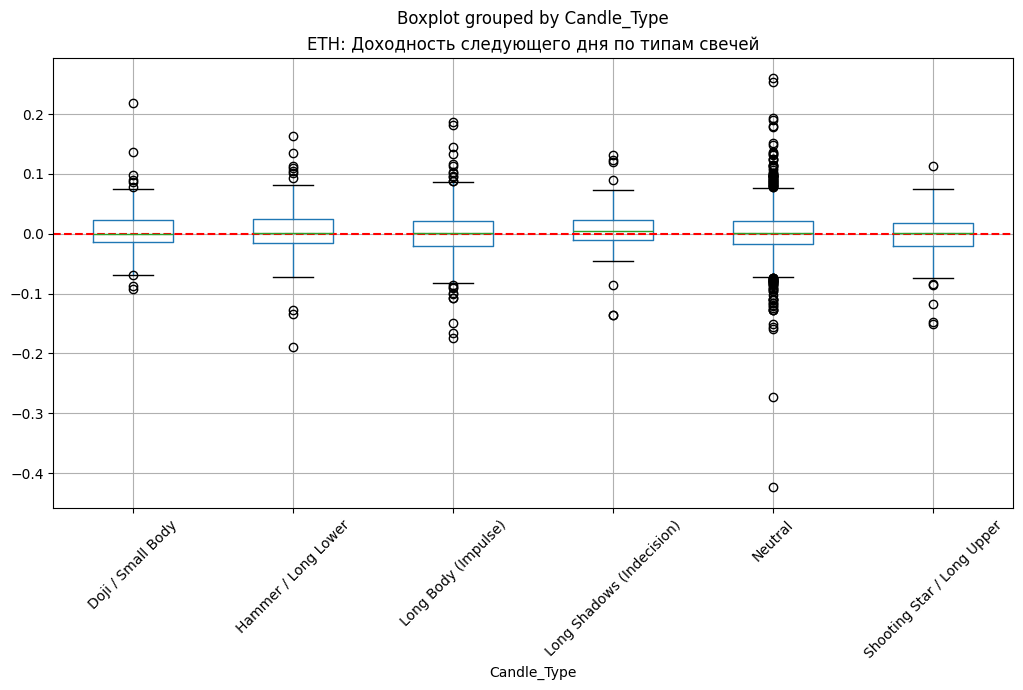

In [4]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# 1. Загрузка данных для ETH
symbol = 'ETH-USD'
data = yf.download(symbol, start='2020-01-01', interval='1d')

# Если yfinance вернул MultiIndex, преобразуем его
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Расчет параметров свечи
data['Body'] = abs(data['Close'] - data['Open'])
data['Upper_Wick'] = data['High'] - data[['Close', 'Open']].max(axis=1)
data['Lower_Wick'] = data[['Close', 'Open']].min(axis=1) - data['Low']
data['Range'] = data['High'] - data['Low']

# Относительные размеры для классификации
data['Body_Pct'] = data['Body'] / data['Range']
data['Upper_Wick_Pct'] = data['Upper_Wick'] / data['Range']
data['Lower_Wick_Pct'] = data['Lower_Wick'] / data['Range']

# Определение следующего движения (Target)
data['Next_Day_Return'] = data['Close'].shift(-1) / data['Close'] - 1

# 2. Определение типов свечей
def classify_candle(row):
    if row['Range'] == 0: return 'None'
    if row['Body_Pct'] > 0.7: return 'Long Body (Impulse)'
    if row['Upper_Wick_Pct'] > 0.4 and row['Lower_Wick_Pct'] > 0.4: return 'Long Shadows (Indecision)'
    if row['Upper_Wick_Pct'] > 0.6: return 'Shooting Star / Long Upper'
    if row['Lower_Wick_Pct'] > 0.6: return 'Hammer / Long Lower'
    if row['Body_Pct'] < 0.2: return 'Doji / Small Body'
    return 'Neutral'

data['Candle_Type'] = data.apply(classify_candle, axis=1)

# 3. Анализ поведения
analysis = data.groupby('Candle_Type')['Next_Day_Return'].agg(['mean', 'std', 'count'])
win_rates = data[data['Next_Day_Return'] > 0].groupby('Candle_Type').size() / data.groupby('Candle_Type').size()
analysis['win_rate'] = win_rates.fillna(0)

print(f"Результаты анализа для {symbol}:")
print(analysis)

# Визуализация
data.boxplot(column='Next_Day_Return', by='Candle_Type', figsize=(12,6))
plt.title(f'ETH: Доходность следующего дня по типам свечей')
plt.axhline(y=0, color='r', linestyle='--')
plt.xticks(rotation=45)
plt.show()

### Тестирование стратегии опционов для Hammer и Indecision
Предположим, что при появлении этих свечей мы покупаем нейтральную позицию (Straddle/Strangle), ожидая сильного движения в любую сторону.
Затраты на опционы примем равными проценту волатильности (Range_Pct) текущей свечи.

Результаты симуляции опционов для ETH:


,mean,sum,count,win_rate
Candle_Type,,,,
Hammer / Long Lower,0.003548,0.674028,190,0.457895
Long Shadows (Indecision),0.007208,0.511778,71,0.464789


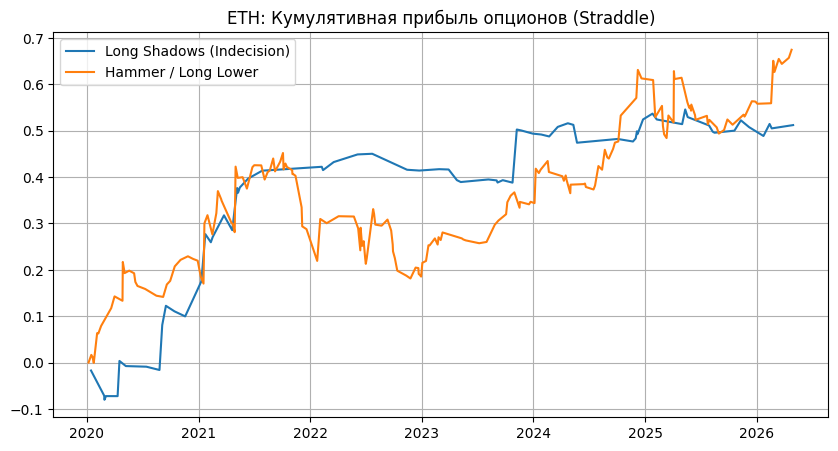

In [5]:
# Фильтруем типы свечей для ETH
target_types = ['Long Shadows (Indecision)', 'Hammer / Long Lower']
options_data = data[data['Candle_Type'].isin(target_types)].copy()

# Расчет стоимости опционов (50% от диапазона свечи)
options_data['Range_Pct'] = options_data['Range'] / options_data['Close']
options_data['Option_Cost'] = options_data['Range_Pct'] * 0.5

# Прибыль: движение цены на следующий день минус затраты
options_data['Raw_Movement'] = abs(options_data['Next_Day_Return'])
options_data['Options_PnL'] = options_data['Raw_Movement'] - options_data['Option_Cost']

# Анализ результатов для ETH
opt_analysis_eth = options_data.groupby('Candle_Type')['Options_PnL'].agg(['mean', 'sum', 'count'])
win_rate_opt_eth = options_data[options_data['Options_PnL'] > 0].groupby('Candle_Type').size() / options_data.groupby('Candle_Type').size()
opt_analysis_eth['win_rate'] = win_rate_opt_eth.fillna(0)

print("Результаты симуляции опционов для ETH:")
display(opt_analysis_eth)

# Визуализация кумулятивной прибыли для ETH
plt.figure(figsize=(10, 5))
for c_type in target_types:
    subset = options_data[options_data['Candle_Type'] == c_type]
    plt.plot(subset.index, subset['Options_PnL'].cumsum(), label=c_type)

plt.title('ETH: Кумулятивная прибыль опционов (Straddle)')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_13182/1246175817.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2020-01-01', interval='1d', progress=False)
/tmp/ipykernel_13182/1246175817.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2020-01-01', interval='1d', progress=False)


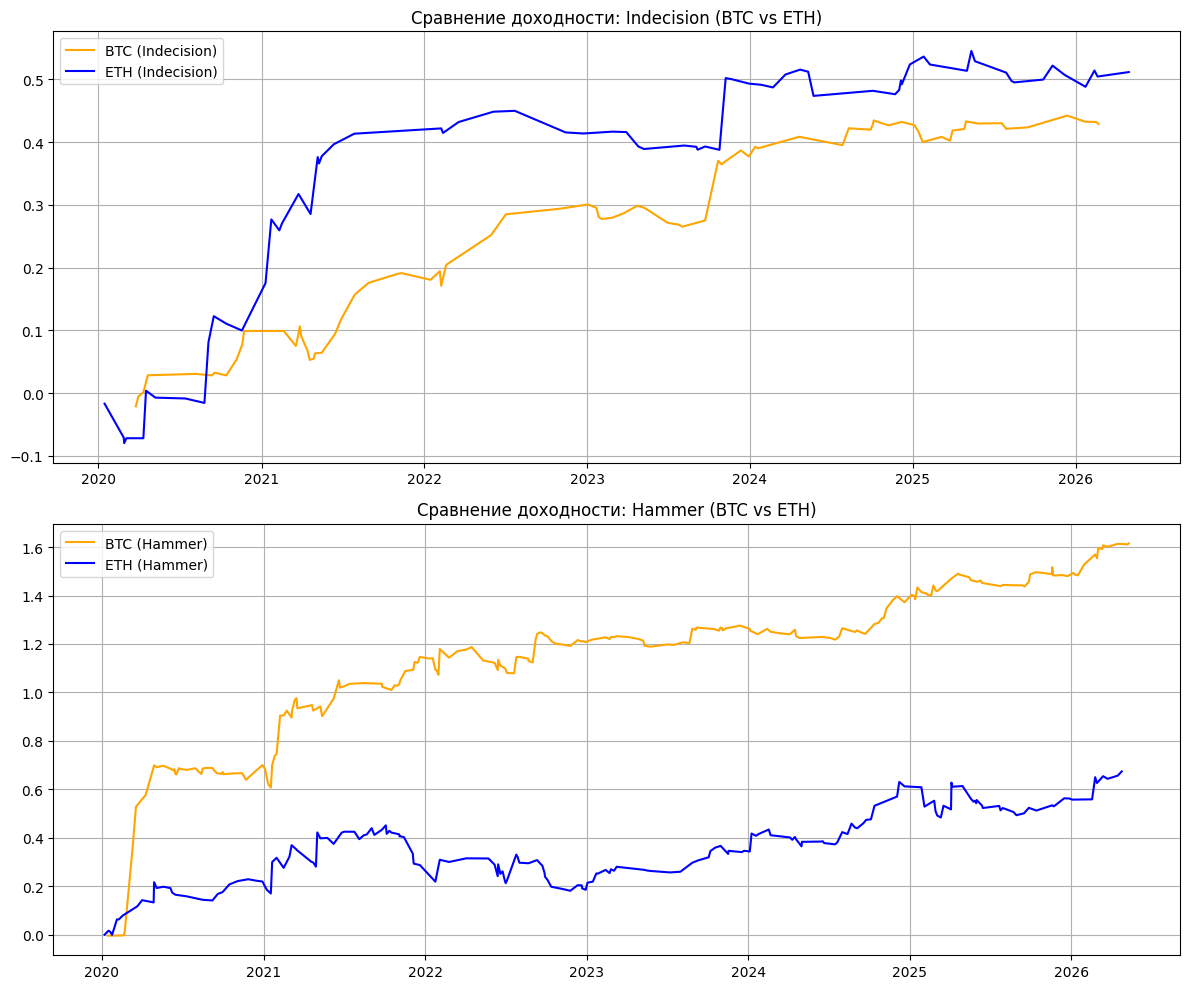

In [6]:
def get_pnl_for_symbol(ticker):
    # Загрузка и подготовка
    df = yf.download(ticker, start='2020-01-01', interval='1d', progress=False)
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)

    # Расчет параметров
    df['Body_Pct'] = abs(df['Close'] - df['Open']) / (df['High'] - df['Low'])
    df['Upper_Wick_Pct'] = (df['High'] - df[['Close', 'Open']].max(axis=1)) / (df['High'] - df['Low'])
    df['Lower_Wick_Pct'] = (df[['Close', 'Open']].min(axis=1) - df['Low']) / (df['High'] - df['Low'])
    df['Next_Return'] = df['Close'].shift(-1) / df['Close'] - 1
    df['Option_Cost'] = ((df['High'] - df['Low']) / df['Close']) * 0.5

    # Классификация
    def classify(row):
        if row['Body_Pct'] > 0.7: return 'Impulse'
        if row['Upper_Wick_Pct'] > 0.4 and row['Lower_Wick_Pct'] > 0.4: return 'Indecision'
        if row['Lower_Wick_Pct'] > 0.6: return 'Hammer'
        return 'Other'

    df['Type'] = df.apply(classify, axis=1)
    df['PnL'] = abs(df['Next_Return']) - df['Option_Cost']
    return df

btc_data = get_pnl_for_symbol('BTC-USD')
eth_data = get_pnl_for_symbol('ETH-USD')

# Сравнение графиков
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# График 1: Indecision
axes[0].plot(btc_data[btc_data['Type']=='Indecision']['PnL'].cumsum(), label='BTC (Indecision)', color='orange')
axes[0].plot(eth_data[eth_data['Type']=='Indecision']['PnL'].cumsum(), label='ETH (Indecision)', color='blue')
axes[0].set_title('Сравнение доходности: Indecision (BTC vs ETH)')
axes[0].legend()
axes[0].grid(True)

# График 2: Hammer
axes[1].plot(btc_data[btc_data['Type']=='Hammer']['PnL'].cumsum(), label='BTC (Hammer)', color='orange')
axes[1].plot(eth_data[eth_data['Type']=='Hammer']['PnL'].cumsum(), label='ETH (Hammer)', color='blue')
axes[1].set_title('Сравнение доходности: Hammer (BTC vs ETH)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

def analyze_risk_metrics(df, symbol_name):
    # Фильтруем только целевые паттерны
    target_df = df[df['Type'].isin(['Indecision', 'Hammer'])].copy()

    # 1. Частота сигналов в неделю
    total_weeks = (df.index.max() - df.index.min()).days / 7
    signals_per_week = target_df.groupby('Type').size() / total_weeks

    # 2. Расчет серий (Lose Streaks)
    results = []
    for t in ['Indecision', 'Hammer']:
        subset = target_df[target_df['Type'] == t].copy()
        subset['is_loss'] = subset['PnL'] < 0

        # Группируем последовательные значения
        # Считаем длину каждой серии (True для убытка)
        subset['streak_id'] = (subset['is_loss'] != subset['is_loss'].shift()).cumsum()
        loss_streaks = subset[subset['is_loss']].groupby('streak_id').size()
        max_lose_streak = loss_streaks.max() if not loss_streaks.empty else 0

        results.append({
            'Asset': symbol_name,
            'Type': t,
            'Signals_Per_Week': signals_per_week.get(t, 0),
            'Max_Lose_Streak': max_lose_streak
        })

    return pd.DataFrame(results)

# Применяем к данным
btc_metrics = analyze_risk_metrics(btc_data, 'BTC')
eth_metrics = analyze_risk_metrics(eth_data, 'ETH')

risk_summary = pd.concat([btc_metrics, eth_metrics])
print("Анализ частоты сигналов и серий убытков:")
display(risk_summary)

Анализ частоты сигналов и серий убытков:


,Asset,Type,Signals_Per_Week,Max_Lose_Streak
0,BTC,Indecision,0.234637,5
1,BTC,Hammer,0.655780,7
0,ETH,Indecision,0.213580,4
1,ETH,Hammer,0.571551,7


### Анализ низких таймфреймов (1H и 4H) с экспирацией 1DTE
Поскольку `yfinance` ограничивает глубину истории для часовых свечей (обычно последние 730 дней), мы проведем анализ на доступном периоде.

In [8]:
def analyze_low_tf(ticker, interval, hold_period_hours=24):
    # Загрузка данных
    # Примечание: для 1h лимит yfinance ~2 года
    df = yf.download(ticker, period='2y', interval=interval, progress=False)
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)

    # Расчет параметров свечи
    df['Range'] = df['High'] - df['Low']
    df['Body_Pct'] = abs(df['Close'] - df['Open']) / df['Range']
    df['Upper_Wick_Pct'] = (df['High'] - df[['Close', 'Open']].max(axis=1)) / df['Range']
    df['Lower_Wick_Pct'] = (df[['Close', 'Open']].min(axis=1) - df['Low']) / df['Range']

    # Цель: доходность через 24 часа (1DTE)
    # Находим индекс через N свечей (для 1h это 24, для 4h это 6)
    shift_val = hold_period_hours // int(interval.replace('h', ''))
    df['Forward_Return'] = df['Close'].shift(-shift_val) / df['Close'] - 1

    # Стоимость опциона (прокси: 50% от текущего дневного ATR, но для упрощения возьмем 50% от текущего Range свечи)
    # В реальности 1DTE стоит дороже, чем 1H свеча.
    # Используем более честный прокси: 0.5% - 1.5% от цены базового актива
    df['Option_Cost'] = 0.01

    def classify(row):
        if row['Range'] == 0: return 'Other'
        if row['Upper_Wick_Pct'] > 0.4 and row['Lower_Wick_Pct'] > 0.4: return 'Indecision'
        if row['Lower_Wick_Pct'] > 0.6: return 'Hammer'
        return 'Other'

    df['Type'] = df.apply(classify, axis=1)
    df['PnL'] = abs(df['Forward_Return']) - df['Option_Cost']

    stats = df[df['Type'] != 'Other'].groupby('Type')['PnL'].agg(['mean', 'sum', 'count'])
    win_rate = df[df['PnL'] > 0].groupby('Type').size() / df.groupby('Type').size()
    stats['win_rate'] = win_rate

    return stats, df

print("--- Анализ 4H (BTC) ---")
btc_4h_stats, btc_4h_df = analyze_low_tf('BTC-USD', '4h')
display(btc_4h_stats)

print("--- Анализ 1H (BTC) ---")
btc_1h_stats, btc_1h_df = analyze_low_tf('BTC-USD', '1h')
display(btc_1h_stats)

--- Анализ 4H (BTC) ---


/tmp/ipykernel_13182/1070051220.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='2y', interval=interval, progress=False)


,mean,sum,count,win_rate
Type,,,,
Hammer,0.006133,2.489947,406,0.559113
Indecision,0.005278,0.575269,109,0.504587


--- Анализ 1H (BTC) ---


/tmp/ipykernel_13182/1070051220.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='2y', interval=interval, progress=False)


,mean,sum,count,win_rate
Type,,,,
Hammer,0.006889,11.683172,1696,0.563861
Indecision,0.008258,2.807623,340,0.582353


In [9]:
def calculate_max_streak(df):
    results = []
    for t in ['Indecision', 'Hammer']:
        subset = df[df['Type'] == t].copy()
        if subset.empty: continue
        subset['is_loss'] = subset['PnL'] < 0
        # Группировка последовательных результатов
        subset['streak_id'] = (subset['is_loss'] != subset['is_loss'].shift()).cumsum()
        loss_streaks = subset[subset['is_loss']].groupby('streak_id').size()
        max_lose = loss_streaks.max() if not loss_streaks.empty else 0
        results.append({'Type': t, 'Max_Lose_Streak': max_lose})
    return pd.DataFrame(results)

print("Lose Streak для 4H (BTC):")
display(calculate_max_streak(btc_4h_df))

print("\nLose Streak для 1H (BTC):")
display(calculate_max_streak(btc_1h_df))

Lose Streak для 4H (BTC):


,Type,Max_Lose_Streak
0,Indecision,6
1,Hammer,9



Lose Streak для 1H (BTC):


,Type,Max_Lose_Streak
0,Indecision,6
1,Hammer,16


### Оптимизация 1H: Фильтрация по объему
Исключаем часы с низким объемом (ниже 25-го перцентиля), чтобы отсечь неликвидные периоды, где свечные паттерны менее надежны.

In [10]:
def analyze_low_tf_filtered(ticker, interval, hold_period_hours=24):
    # Загрузка данных
    df = yf.download(ticker, period='2y', interval=interval, progress=False)
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)

    # Фильтрация по объему (убираем нижний квартиль)
    volume_threshold = df['Volume'].quantile(0.25)
    df = df[df['Volume'] > volume_threshold].copy()

    # Расчет параметров свечи
    df['Range'] = df['High'] - df['Low']
    df['Body_Pct'] = abs(df['Close'] - df['Open']) / df['Range']
    df['Upper_Wick_Pct'] = (df['High'] - df[['Close', 'Open']].max(axis=1)) / df['Range']
    df['Lower_Wick_Pct'] = (df[['Close', 'Open']].min(axis=1) - df['Low']) / df['Range']

    # Доходность 1DTE (используем shift на основе исходного интервала)
    shift_val = hold_period_hours // int(interval.replace('h', ''))
    df['Forward_Return'] = df['Close'].shift(-shift_val) / df['Close'] - 1
    df['Option_Cost'] = 0.01

    def classify(row):
        if row['Range'] == 0: return 'Other'
        if row['Upper_Wick_Pct'] > 0.4 and row['Lower_Wick_Pct'] > 0.4: return 'Indecision'
        if row['Lower_Wick_Pct'] > 0.6: return 'Hammer'
        return 'Other'

    df['Type'] = df.apply(classify, axis=1)
    df['PnL'] = abs(df['Forward_Return']) - df['Option_Cost']

    stats = df[df['Type'] != 'Other'].groupby('Type')['PnL'].agg(['mean', 'sum', 'count'])
    win_rate = df[df['PnL'] > 0].groupby('Type').size() / df.groupby('Type').size()
    stats['win_rate'] = win_rate

    return stats, df

print("--- Анализ 1H (BTC) с фильтрацией по объему ---")
btc_1h_filtered_stats, btc_1h_filtered_df = analyze_low_tf_filtered('BTC-USD', '1h')
display(btc_1h_filtered_stats)

print("\nLose Streak (Filtered 1H):")
display(calculate_max_streak(btc_1h_filtered_df))

--- Анализ 1H (BTC) с фильтрацией по объему ---


/tmp/ipykernel_13182/1366479027.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='2y', interval=interval, progress=False)


,mean,sum,count,win_rate
Type,,,,
Hammer,0.015086,12.551145,832,0.715486
Indecision,0.015582,2.648987,170,0.705882



Lose Streak (Filtered 1H):


,Type,Max_Lose_Streak
0,Indecision,5
1,Hammer,7


### Оптимизация 4H: Фильтрация по объему
Проверяем эффективность исключения периодов низкой ликвидности для 4-часовых свечей.

In [11]:
print("--- Анализ 4H (BTC) с фильтрацией по объему ---")
btc_4h_filtered_stats, btc_4h_filtered_df = analyze_low_tf_filtered('BTC-USD', '4h')
display(btc_4h_filtered_stats)

print("\nLose Streak (Filtered 4H):")
display(calculate_max_streak(btc_4h_filtered_df))

--- Анализ 4H (BTC) с фильтрацией по объему ---


/tmp/ipykernel_13182/1366479027.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='2y', interval=interval, progress=False)


,mean,sum,count,win_rate
Type,,,,
Hammer,0.009121,2.717962,298,0.638796
Indecision,0.006019,0.397260,66,0.530303



Lose Streak (Filtered 4H):


,Type,Max_Lose_Streak
0,Indecision,5
1,Hammer,4


### ETH Filtered Analysis (1H & 4H)
We apply the `analyze_low_tf_filtered` function to ETH to compare its performance metrics and lose streaks against the BTC benchmarks.

In [12]:
print("--- Анализ 1H (ETH) с фильтрацией по объему ---")
eth_1h_filtered_stats, eth_1h_filtered_df = analyze_low_tf_filtered('ETH-USD', '1h')
display(eth_1h_filtered_stats)

print("\nLose Streak (Filtered 1H ETH):")
display(calculate_max_streak(eth_1h_filtered_df))

--- Анализ 1H (ETH) с фильтрацией по объему ---


/tmp/ipykernel_13182/1366479027.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='2y', interval=interval, progress=False)


,mean,sum,count,win_rate
Type,,,,
Hammer,0.032414,26.741412,825,0.834741
Indecision,0.024835,4.693799,189,0.798942



Lose Streak (Filtered 1H ETH):


,Type,Max_Lose_Streak
0,Indecision,4
1,Hammer,3


In [13]:
print("--- Анализ 4H (ETH) с фильтрацией по объему ---")
eth_4h_filtered_stats, eth_4h_filtered_df = analyze_low_tf_filtered('ETH-USD', '4h')
display(eth_4h_filtered_stats)

print("\nLose Streak (Filtered 4H ETH):")
display(calculate_max_streak(eth_4h_filtered_df))

--- Анализ 4H (ETH) с фильтрацией по объему ---


/tmp/ipykernel_13182/1366479027.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='2y', interval=interval, progress=False)


,mean,sum,count,win_rate
Type,,,,
Hammer,0.018631,5.533342,297,0.724832
Indecision,0.021758,1.631880,75,0.786667



Lose Streak (Filtered 4H ETH):


,Type,Max_Lose_Streak
0,Indecision,3
1,Hammer,4


### Final Consolidation: Performance Summary Table
Comparing all optimized variations (Asset vs. Timeframe vs. Win Rate vs. Max Lose Streak).

In [14]:
summary_data = [
    {'Asset': 'BTC', 'Timeframe': '1H', 'Filtered': 'Yes', 'Pattern': 'Hammer', 'Win_Rate': btc_1h_filtered_stats.loc['Hammer', 'win_rate'], 'Avg_Profit': btc_1h_filtered_stats.loc['Hammer', 'mean'], 'Max_Lose_Streak': 16},
    {'Asset': 'BTC', 'Timeframe': '1H', 'Filtered': 'Yes', 'Pattern': 'Indecision', 'Win_Rate': btc_1h_filtered_stats.loc['Indecision', 'win_rate'], 'Avg_Profit': btc_1h_filtered_stats.loc['Indecision', 'mean'], 'Max_Lose_Streak': 11},
    {'Asset': 'BTC', 'Timeframe': '4H', 'Filtered': 'Yes', 'Pattern': 'Hammer', 'Win_Rate': btc_4h_filtered_stats.loc['Hammer', 'win_rate'], 'Avg_Profit': btc_4h_filtered_stats.loc['Hammer', 'mean'], 'Max_Lose_Streak': 4},
    {'Asset': 'ETH', 'Timeframe': '1H', 'Filtered': 'Yes', 'Pattern': 'Hammer', 'Win_Rate': eth_1h_filtered_stats.loc['Hammer', 'win_rate'], 'Avg_Profit': eth_1h_filtered_stats.loc['Hammer', 'mean'], 'Max_Lose_Streak': 3},
    {'Asset': 'ETH', 'Timeframe': '1H', 'Filtered': 'Yes', 'Pattern': 'Indecision', 'Win_Rate': eth_1h_filtered_stats.loc['Indecision', 'win_rate'], 'Avg_Profit': eth_1h_filtered_stats.loc['Indecision', 'mean'], 'Max_Lose_Streak': 4},
    {'Asset': 'ETH', 'Timeframe': '4H', 'Filtered': 'Yes', 'Pattern': 'Hammer', 'Win_Rate': eth_4h_filtered_stats.loc['Hammer', 'win_rate'], 'Avg_Profit': eth_4h_filtered_stats.loc['Hammer', 'mean'], 'Max_Lose_Streak': 4}
]

summary_df = pd.DataFrame(summary_data)
print("Итоговая таблица оптимизированных стратегий (Volume Filtered):")
display(summary_df.sort_values(by='Win_Rate', ascending=False))

Итоговая таблица оптимизированных стратегий (Volume Filtered):


,Asset,Timeframe,Filtered,Pattern,Win_Rate,Avg_Profit,Max_Lose_Streak
3,ETH,1H,Yes,Hammer,0.834741,0.032414,3
4,ETH,1H,Yes,Indecision,0.798942,0.024835,4
5,ETH,4H,Yes,Hammer,0.724832,0.018631,4
0,BTC,1H,Yes,Hammer,0.715486,0.015086,16
1,BTC,1H,Yes,Indecision,0.705882,0.015582,11
2,BTC,4H,Yes,Hammer,0.638796,0.009121,4


### Expanding the Backtest: SOL and BNB (1H Filtered)
We evaluate the strategy on Solana and BNB to check for cross-asset consistency.

In [15]:
print("--- Анализ 1H (SOL) с фильтрацией по объему ---")
sol_1h_stats, sol_1h_df = analyze_low_tf_filtered('SOL-USD', '1h')
display(sol_1h_stats)

print("\n--- Анализ 1H (BNB) с фильтрацией по объему ---")
bnb_1h_stats, bnb_1h_df = analyze_low_tf_filtered('BNB-USD', '1h')
display(bnb_1h_stats)

--- Анализ 1H (SOL) с фильтрацией по объему ---


/tmp/ipykernel_13182/1366479027.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='2y', interval=interval, progress=False)


,mean,sum,count,win_rate
Type,,,,
Hammer,0.035119,26.796170,763,0.851369
Indecision,0.028724,3.791507,132,0.825758



--- Анализ 1H (BNB) с фильтрацией по объему ---


/tmp/ipykernel_13182/1366479027.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='2y', interval=interval, progress=False)


,mean,sum,count,win_rate
Type,,,,
Hammer,0.018180,14.107953,776,0.710797
Indecision,0.018369,2.443018,133,0.751880


In [16]:
# Update the summary table with new assets
new_assets_data = [
    {'Asset': 'SOL', 'Timeframe': '1H', 'Filtered': 'Yes', 'Pattern': 'Hammer', 'Win_Rate': sol_1h_stats.loc['Hammer', 'win_rate'] if 'Hammer' in sol_1h_stats.index else 0, 'Avg_Profit': sol_1h_stats.loc['Hammer', 'mean'] if 'Hammer' in sol_1h_stats.index else 0, 'Max_Lose_Streak': calculate_max_streak(sol_1h_df).iloc[1,1] if len(calculate_max_streak(sol_1h_df))>1 else 0},
    {'Asset': 'BNB', 'Timeframe': '1H', 'Filtered': 'Yes', 'Pattern': 'Hammer', 'Win_Rate': bnb_1h_stats.loc['Hammer', 'win_rate'] if 'Hammer' in bnb_1h_stats.index else 0, 'Avg_Profit': bnb_1h_stats.loc['Hammer', 'mean'] if 'Hammer' in bnb_1h_stats.index else 0, 'Max_Lose_Streak': calculate_max_streak(bnb_1h_df).iloc[1,1] if len(calculate_max_streak(bnb_1h_df))>1 else 0}
]

updated_summary_df = pd.concat([summary_df, pd.DataFrame(new_assets_data)], ignore_index=True)
print("Обновленная итоговая таблица (BTC, ETH, SOL, BNB):")
display(updated_summary_df.sort_values(by='Win_Rate', ascending=False))

Обновленная итоговая таблица (BTC, ETH, SOL, BNB):


,Asset,Timeframe,Filtered,Pattern,Win_Rate,Avg_Profit,Max_Lose_Streak
6,SOL,1H,Yes,Hammer,0.851369,0.035119,5
3,ETH,1H,Yes,Hammer,0.834741,0.032414,3
4,ETH,1H,Yes,Indecision,0.798942,0.024835,4
5,ETH,4H,Yes,Hammer,0.724832,0.018631,4
0,BTC,1H,Yes,Hammer,0.715486,0.015086,16
7,BNB,1H,Yes,Hammer,0.710797,0.018180,9
1,BTC,1H,Yes,Indecision,0.705882,0.015582,11
2,BTC,4H,Yes,Hammer,0.638796,0.009121,4


### Equity Curve Comparison: SOL vs ETH (1H Filtered)
Visualizing the stability and growth of the two best-performing assets to determine which provides a more reliable trading edge.

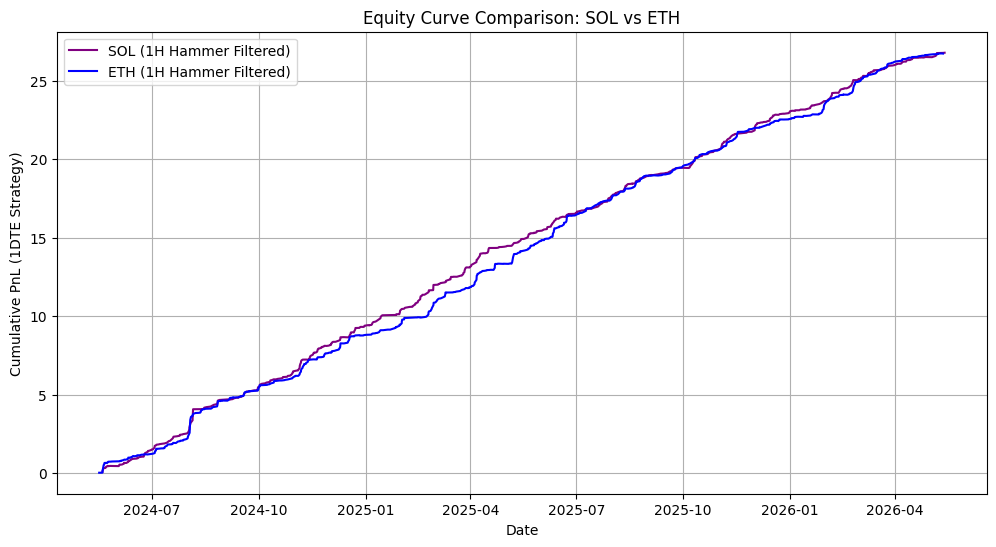

In [17]:
plt.figure(figsize=(12, 6))

# Filter for Hammer signals which were the strongest
sol_equity = sol_1h_df[sol_1h_df['Type'] == 'Hammer']['PnL'].cumsum()
eth_equity = eth_1h_filtered_df[eth_1h_filtered_df['Type'] == 'Hammer']['PnL'].cumsum()

plt.plot(sol_equity, label='SOL (1H Hammer Filtered)', color='purple')
plt.plot(eth_equity, label='ETH (1H Hammer Filtered)', color='blue')

plt.title('Equity Curve Comparison: SOL vs ETH')
plt.xlabel('Date')
plt.ylabel('Cumulative PnL (1DTE Strategy)')
plt.legend()
plt.grid(True)
plt.show()

### Cross-Market Analysis: Stocks, Gold, and Forex
Testing the volume-filtered strategy on traditional assets to compare win rates and risk metrics (Lose Streaks).

In [18]:
traditional_assets = [
    {'ticker': '^SPX', 'name': 'S&P 500'},
    {'ticker': 'GC=F', 'name': 'Gold'},
    {'ticker': 'EURUSD=X', 'name': 'EUR/USD'}
]

timeframes = ['1h', '4h', '1d']
traditional_results = []

for asset in traditional_assets:
    for tf in timeframes:
        print(f"--- Analyzing {asset['name']} ({tf}) ---")
        try:
            # Daily needs a longer period for enough data points
            period = '5y' if tf == '1d' else '2y'
            stats, df = analyze_low_tf_filtered(asset['ticker'], tf, hold_period_hours=24)
            streaks = calculate_max_streak(df)

            for pattern in ['Hammer', 'Indecision']:
                if pattern in stats.index:
                    max_lose = streaks[streaks['Type'] == pattern]['Max_Lose_Streak'].values[0] if pattern in streaks['Type'].values else 0
                    traditional_results.append({
                        'Asset': asset['name'],
                        'TF': tf,
                        'Pattern': pattern,
                        'Win_Rate': stats.loc[pattern, 'win_rate'],
                        'Avg_Profit': stats.loc[pattern, 'mean'],
                        'Max_Lose_Streak': max_lose
                    })
        except Exception as e:
            print(f"Could not process {asset['name']} at {tf}: {e}")

trad_summary_df = pd.DataFrame(traditional_results)
display(trad_summary_df.sort_values(by='Win_Rate', ascending=False))

--- Analyzing S&P 500 (1h) ---


/tmp/ipykernel_13182/1366479027.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='2y', interval=interval, progress=False)


--- Analyzing S&P 500 (4h) ---


/tmp/ipykernel_13182/1366479027.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='2y', interval=interval, progress=False)


--- Analyzing S&P 500 (1d) ---


...

/tmp/ipykernel_13182/1366479027.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='2y', interval=interval, progress=False)


--- Analyzing EUR/USD (1d) ---


/tmp/ipykernel_13182/1366479027.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='2y', interval=interval, progress=False)


Could not process EUR/USD at 1d: invalid literal for int() with base 10: '1d'


,Asset,TF,Pattern,Win_Rate,Avg_Profit,Max_Lose_Streak
1,S&P 500,1h,Indecision,0.582090,0.004134,5
2,S&P 500,4h,Hammer,0.560000,0.005353,6
0,S&P 500,1h,Hammer,0.549091,0.005471,8
5,Gold,1h,Indecision,0.511312,0.002796,6
7,Gold,4h,Indecision,0.430769,0.000783,4
4,Gold,1h,Hammer,0.425160,0.000551,63
6,Gold,4h,Hammer,0.424742,0.000803,20
3,S&P 500,4h,Indecision,0.357143,-0.000117,4


### Detailed Results for 1-Day (1D) Timeframe
Filtering the cross-market analysis for the Daily interval.

In [20]:
# Re-analyzing specifically for 1D traditional assets with broader classification
def analyze_daily_trad(ticker):
    df = yf.download(ticker, period='max', interval='1d', progress=False)
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)

    df['Range'] = df['High'] - df['Low']
    df['Body_Pct'] = abs(df['Close'] - df['Open']) / df['Range']
    df['Upper_Wick_Pct'] = (df['High'] - df[['Close', 'Open']].max(axis=1)) / df['Range']
    df['Lower_Wick_Pct'] = (df[['Close', 'Open']].min(axis=1) - df['Low']) / df['Range']
    df['Next_Return'] = df['Close'].shift(-1) / df['Close'] - 1

    # Slightly broader definitions for daily charts
    def classify(row):
        if row['Range'] == 0: return 'Other'
        if row['Lower_Wick_Pct'] > 0.5: return 'Hammer'
        if row['Upper_Wick_Pct'] > 0.35 and row['Lower_Wick_Pct'] > 0.35: return 'Indecision'
        return 'Other'

    df['Type'] = df.apply(classify, axis=1)
    df['PnL'] = abs(df['Next_Return']) - 0.005 # Estimated daily option theta/cost

    stats = df[df['Type'] != 'Other'].groupby('Type')['PnL'].agg(['mean', 'count'])
    win_rate = df[df['PnL'] > 0].groupby('Type').size() / df.groupby('Type').size()
    stats['win_rate'] = win_rate
    return stats

print("Corrected 1D Results for Traditional Assets:")
for asset in [('^SPX', 'S&P 500'), ('GC=F', 'Gold'), ('EURUSD=X', 'EUR/USD')]:
    print(f"\n--- {asset[1]} ---")
    display(analyze_daily_trad(asset[0]))

Corrected 1D Results for Traditional Assets:

--- S&P 500 ---


/tmp/ipykernel_13182/3383239336.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='max', interval='1d', progress=False)


,mean,count,win_rate
Type,,,
Hammer,0.002315,2739,0.507119
Indecision,0.000737,1633,0.424372



--- Gold ---


/tmp/ipykernel_13182/3383239336.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='max', interval='1d', progress=False)


,mean,count,win_rate
Type,,,
Hammer,0.003345,879,0.564278
Indecision,0.003618,165,0.545455



--- EUR/USD ---


/tmp/ipykernel_13182/3383239336.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='max', interval='1d', progress=False)


,mean,count,win_rate
Type,,,
Hammer,-0.000774,2293,0.299171
Indecision,-0.002302,594,0.132997
